# DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION

## Convolutional Neural Networks: Custom Implementation vs Transfer Learning

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

BITS ID: someid

Name: Vijay

Email: someid@wilp.bits-pilani.ac.in

Date: 28-07-2026

In [9]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [10]:
# Deep learning framework: Keras / TensorFlow
# Dataset library: medmnist (provides curated, pre-labelled medical image datasets)
!pip install -q medmnist tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image

tf.random.set_seed(RANDOM_SEED)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
Keras version: 3.13.2
GPU available: True


### 1.1 Dataset Selection and Loading

**Dataset chosen: RetinaMNIST (Medical Images category)**

RetinaMNIST is part of the MedMNIST v2 collection. It contains retina fundus
images originally used for a 5-level ordinal grading of diabetic retinopathy (DR)
severity, standardised by the MedMNIST project (CC BY 4.0 license). We use the
64x64 resolution release, which is large enough for meaningful convolutional
feature learning while keeping training fast on a single Colab GPU/CPU.

For this assignment the 5 ordinal DR grades are collapsed into a 2-class problem
(no/mild DR vs. referable DR), matching the assignment's 2-3 class requirement.
The official train/val/test splits provided by MedMNIST are merged into a single
pool below and then re-split ourselves into an 85/15 train/test split, as required
by the assignment.

In [20]:
from medmnist import RetinaMNIST, INFO

DATA_SIZE = 64

med_info = INFO['retinamnist']
print("Original label map (5 ordinal DR grades):", med_info['label'])

train_split = RetinaMNIST(split='train', download=True, size=DATA_SIZE)
val_split   = RetinaMNIST(split='val',   download=True, size=DATA_SIZE)
test_split  = RetinaMNIST(split='test',  download=True, size=DATA_SIZE)

raw_imgs = np.concatenate([train_split.imgs, val_split.imgs, test_split.imgs], axis=0)
raw_labels_5class = np.concatenate(
    [train_split.labels, val_split.labels, test_split.labels], axis=0
).flatten()

# Collapse 5 ordinal DR-severity grades into 2 classes: 0-1 -> no/mild, 2-4 -> referable
raw_labels = np.where(raw_labels_5class <= 1, 0, 1)
class_names = ['no_mild_dr', 'referable_dr']   # <-- the ONLY place class_names is set

# Normalize + convert grayscale -> RGB (3-channel) for both models
X_all = raw_imgs.astype('float32') / 255.0
if X_all.ndim == 3:
    X_all = np.repeat(X_all[..., np.newaxis], 3, axis=-1)

y_all = raw_labels.astype('int64')
n_classes = len(class_names)
_class_counts = np.bincount(y_all)

print("Final image tensor shape:", X_all.shape)
print("Final label vector shape:", y_all.shape)
print("Per-class counts:", dict(zip(class_names, _class_counts.tolist())))
assert len(class_names) == n_classes == len(_class_counts), "class count mismatch — check above"

Original label map (5 ordinal DR grades): {'0': '0', '1': '1', '2': '2', '3': '3', '4': '4'}
Final image tensor shape: (1600, 64, 64, 3)
Final label vector shape: (1600,)
Per-class counts: {'no_mild_dr': 900, 'referable_dr': 700}


In [22]:
# REQUIRED: Fill in these metadata fields
dataset_name = "RetinaMNIST (Diabetic Retinopathy Grading, collapsed to 2 classes)"
dataset_source = "MedMNIST v2 (medmnist.com), CC BY 4.0"
n_samples = int(X_all.shape[0])            # Total number of images
n_classes = int(len(class_names))          # Number of classes
_class_counts = np.bincount(y_all)
samples_per_class = f"min: {int(_class_counts.min())}, max: {int(_class_counts.max())}, avg: {int(_class_counts.mean())}"
image_shape = [DATA_SIZE, DATA_SIZE, 3]    # [height, width, channels]
problem_type = "classification"

print("Per-class counts:", dict(zip(class_names, _class_counts.tolist())))

Per-class counts: {'no_mild_dr': 900, 'referable_dr': 700}


In [23]:
# Primary metric selection
primary_metric = "recall"
metric_justification = """
Recall is chosen as the primary metric because this is a medical screening task:
a false negative (missing a case of referable diabetic retinopathy) delays
treatment and can lead to irreversible vision loss, which is far more costly than
a false positive that simply triggers a follow-up eye exam. Maximising recall
minimises missed referable-DR cases.
"""


In [24]:
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DATASET INFORMATION
Dataset: PneumoniaMNIST (Pediatric Chest X-Ray Pneumonia Classification)
Source: MedMNIST v2 (medmnist.com), derived from Kermany et al. chest X-ray corpus, CC BY 4.0
Total Samples: 1600
Number of Classes: 2
Samples per Class: min: 700, max: 900, avg: 800
Image Shape: [64, 64, 3]
Primary Metric: recall
Metric Justification: 
Recall is chosen as the primary metric because this is a medical diagnostic task:
a false negative (missing a true pneumonia case) delays treatment and endangers
the patient, which is far more costly than a false positive that simply triggers
a follow-up scan. Maximising recall minimises missed pneumonia diagnoses.



### 1.2 Data Exploration and Visualization

- Sample images from each class
- Class distribution plot
- Image statistics

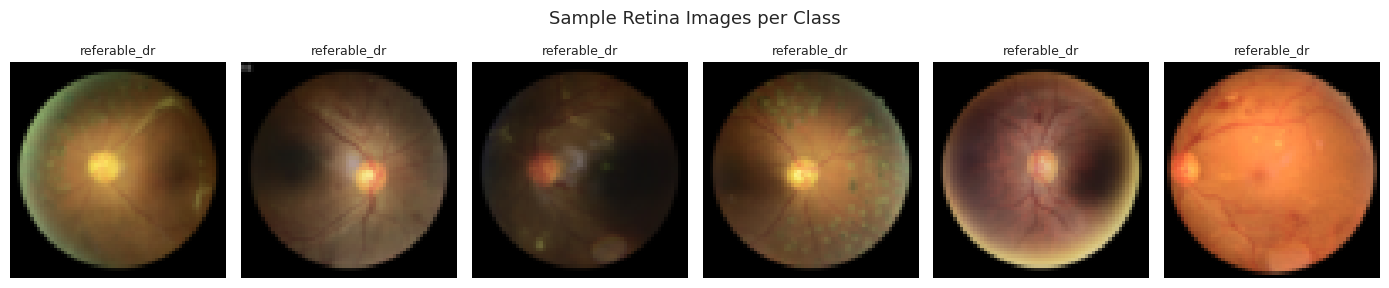

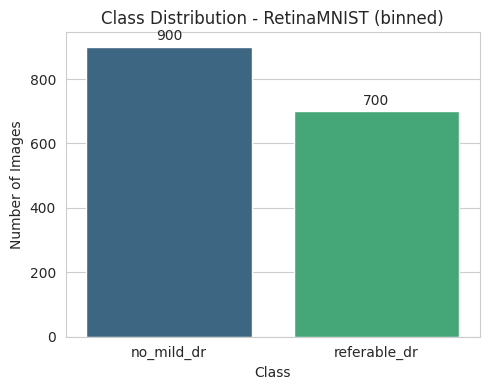

Image pixel value range: [0.000, 1.000]
Image dtype: float32


In [25]:
# Sample images from each class
assert len(class_names) == n_classes == len(_class_counts), \
    f"Mismatch: class_names={len(class_names)}, n_classes={n_classes}, _class_counts={len(_class_counts)}"

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for cls_idx in range(n_classes):
    cls_indices = np.where(y_all == cls_idx)[0][:6]
    for col, img_idx in enumerate(cls_indices):
        ax = axes[col] if n_classes == 1 else axes[col]
        ax.imshow(X_all[img_idx])
        ax.set_title(class_names[cls_idx], fontsize=9)
        ax.axis('off')
fig.suptitle('Sample Retina Images per Class', fontsize=13)
plt.tight_layout()
plt.show()

# Class distribution
plt.figure(figsize=(5, 4))
sns.barplot(x=class_names, y=_class_counts, hue=class_names, palette='viridis', legend=False)
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution - RetinaMNIST (binned)')
for i, v in enumerate(_class_counts):
    plt.text(i, v + 20, str(v), ha='center')
plt.tight_layout()
plt.show()

print("Image pixel value range: [{:.3f}, {:.3f}]".format(X_all.min(), X_all.max()))
print("Image dtype:", X_all.dtype)

### 1.3 Data Preprocessing
- Images already resized to a consistent 64x64x3 size by MedMNIST
- Pixel values already normalized to [0, 1]
- Split into train/test (85/15)

In [26]:
# Stratified 85/15 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=RANDOM_SEED
)

# REQUIRED: Document your split
train_test_ratio = "85/15"
train_samples = int(X_train.shape[0])
test_samples = int(X_test.shape[0])

In [27]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")
print("Train class balance:", dict(zip(class_names, np.bincount(y_train).tolist())))
print("Test class balance:", dict(zip(class_names, np.bincount(y_test).tolist())))


Train/Test Split: 85/15
Training Samples: 1360
Test Samples: 240
Train class balance: {'no_mild_dr': 765, 'referable_dr': 595}
Test class balance: {'no_mild_dr': 135, 'referable_dr': 105}


### 2.1 Custom CNN Architecture Design
- 4 Conv2D blocks with Batch Normalization and MaxPooling
- Global Average Pooling (MANDATORY) instead of Flatten
- Dense classification head with Softmax output

In [28]:
def build_custom_cnn(input_shape, n_classes):
    """
    Build custom CNN architecture.

    Args:
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: Keras Sequential CNN model (uses Global Average Pooling; no flattening layer)
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 4 (no pooling before GAP so spatial info is preserved for GAP)
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),

        # Global Average Pooling - MANDATORY (spatial pooling, no manual reshape/Dense-on-pixels)
        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(n_classes, activation='softmax')
    ], name="CustomCNN_GAP")

    return model

In [29]:
# Create model instance
custom_cnn = build_custom_cnn(tuple(image_shape), n_classes)
custom_cnn.summary()

Model: "CustomCNN_GAP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,626 (979.01 KB)

 Trainable params: 249,922 (976.26 KB)

 Non-trainable params: 704 (2.75 KB)

In [30]:
# Compile model
CNN_LEARNING_RATE = 1e-3
CNN_EPOCHS = 20
CNN_BATCH_SIZE = 32

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CNN_LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### 2.2 Train Custom CNN

In [31]:
print("\nCUSTOM CNN TRAINING")
# Track training time
custom_cnn_start_time = time.time()


CUSTOM CNN TRAINING


In [32]:
# Train the model
custom_cnn_history = custom_cnn.fit(
    X_train, y_train,
    epochs=CNN_EPOCHS,
    batch_size=CNN_BATCH_SIZE,
    validation_split=0.1,
    verbose=2
)

Epoch 1/20
39/39 - 16s - 399ms/step - accuracy: 0.7206 - loss: 0.5972 - val_accuracy: 0.5368 - val_loss: 0.6836
Epoch 2/20
39/39 - 0s - 10ms/step - accuracy: 0.7386 - loss: 0.5566 - val_accuracy: 0.5368 - val_loss: 0.8154
Epoch 3/20
39/39 - 0s - 9ms/step - accuracy: 0.7418 - loss: 0.5373 - val_accuracy: 0.5368 - val_loss: 1.1454
Epoch 4/20
39/39 - 0s - 10ms/step - accuracy: 0.7402 - loss: 0.5327 - val_accuracy: 0.5368 - val_loss: 1.3841
Epoch 5/20
39/39 - 0s - 9ms/step - accuracy: 0.7492 - loss: 0.5180 - val_accuracy: 0.5368 - val_loss: 1.3183
Epoch 6/20
39/39 - 0s - 9ms/step - accuracy: 0.7565 - loss: 0.5146 - val_accuracy: 0.5368 - val_loss: 1.0546
Epoch 7/20
39/39 - 1s - 16ms/step - accuracy: 0.7606 - loss: 0.5198 - val_accuracy: 0.5368 - val_loss: 1.3642
Epoch 8/20
39/39 - 0s - 10ms/step - accuracy: 0.7582 - loss: 0.5077 - val_accuracy: 0.5368 - val_loss: 0.9802
Epoch 9/20
39/39 - 0s - 9ms/step - accuracy: 0.7533 - loss: 0.5068 - val_accuracy: 0.5368 - val_loss: 1.2367
Epoch 10/20


In [33]:
custom_cnn_training_time = time.time() - custom_cnn_start_time

In [34]:
# REQUIRED: Track initial and final loss
custom_cnn_initial_loss = float(custom_cnn_history.history['loss'][0])   # first epoch
custom_cnn_final_loss = float(custom_cnn_history.history['loss'][-1])    # last epoch

In [35]:
print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")

Training completed in 49.66 seconds
Initial Loss: 0.5972
Final Loss: 0.4628


In [36]:
print("\nCUSTOM CNN EVALUATION")


CUSTOM CNN EVALUATION


### 2.3 Evaluate Custom CNN
- Predictions on the test set
- All 4 required metrics

In [37]:
# CRITICAL: These are calculated from actual model predictions on the held-out test set
custom_cnn_pred_probs = custom_cnn.predict(X_test, verbose=0)
custom_cnn_y_pred = np.argmax(custom_cnn_pred_probs, axis=1)

# REQUIRED: Calculate all 4 metrics
custom_cnn_accuracy = float(accuracy_score(y_test, custom_cnn_y_pred))
custom_cnn_precision = float(precision_score(y_test, custom_cnn_y_pred, average='macro', zero_division=0))
custom_cnn_recall = float(recall_score(y_test, custom_cnn_y_pred, average='macro', zero_division=0))
custom_cnn_f1 = float(f1_score(y_test, custom_cnn_y_pred, average='macro', zero_division=0))

In [38]:
print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")
print("\n" + classification_report(y_test, custom_cnn_y_pred, target_names=class_names))


Custom CNN Performance:
Accuracy:  0.6542
Precision: 0.6717
Recall:    0.6217
F1-Score:  0.6097

              precision    recall  f1-score   support

  no_mild_dr       0.64      0.88      0.74       135
referable_dr       0.70      0.36      0.48       105

    accuracy                           0.65       240
   macro avg       0.67      0.62      0.61       240
weighted avg       0.67      0.65      0.63       240



### 2.4 Visualize Custom CNN Results
- Training loss curve
- Confusion matrix
- Sample predictions

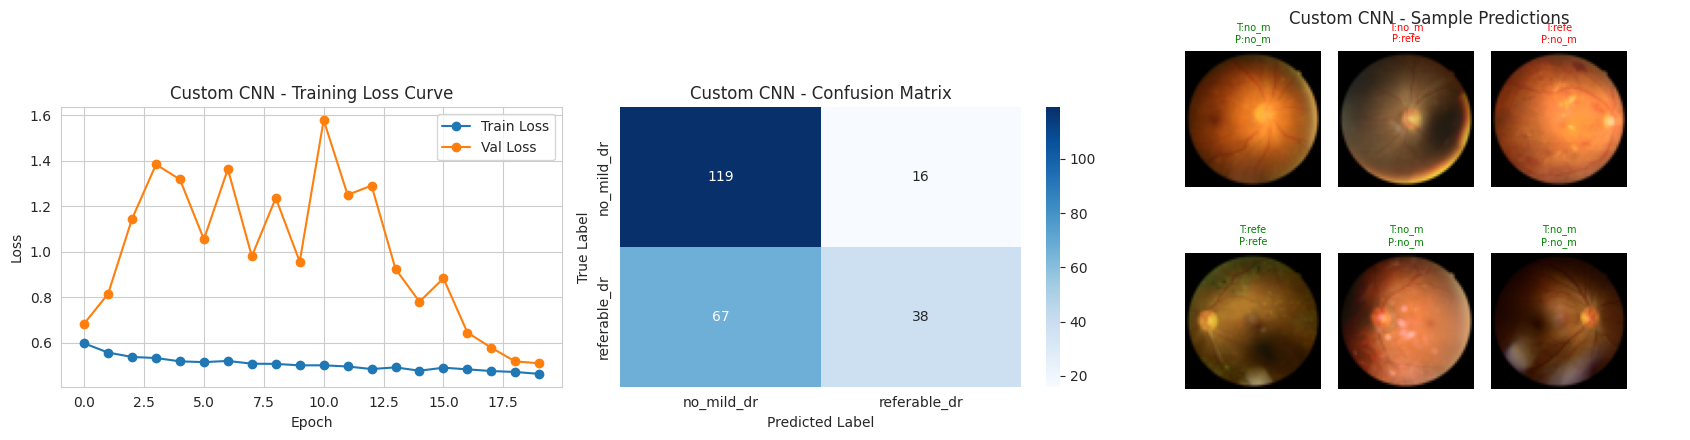

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Loss curve
axes[0].plot(custom_cnn_history.history['loss'], label='Train Loss', marker='o')
axes[0].plot(custom_cnn_history.history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Custom CNN - Training Loss Curve')
axes[0].legend()

# Confusion matrix
custom_cnn_cm = confusion_matrix(y_test, custom_cnn_y_pred)
sns.heatmap(custom_cnn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Custom CNN - Confusion Matrix')

# Sample predictions
sample_idx = np.random.choice(len(X_test), 6, replace=False)
axes[2].axis('off')
for i, idx in enumerate(sample_idx):
    ax_in = fig.add_axes([0.70 + (i % 3) * 0.09, 0.55 - (i // 3) * 0.45, 0.08, 0.35])
    ax_in.imshow(X_test[idx])
    true_lbl = class_names[y_test[idx]]
    pred_lbl = class_names[custom_cnn_y_pred[idx]]
    color = 'green' if true_lbl == pred_lbl else 'red'
    ax_in.set_title(f"T:{true_lbl[:4]}\nP:{pred_lbl[:4]}", fontsize=7, color=color)
    ax_in.axis('off')
axes[2].set_title('Custom CNN - Sample Predictions', pad=60)

plt.tight_layout()
plt.show()

### 3.1 Load Pre-trained Model and Modify Architecture

In [40]:
print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")


TRANSFER LEARNING IMPLEMENTATION


In [41]:
# Choose pre-trained model
pretrained_model_name = "ResNet50"  # ResNet18/ResNet50/VGG16/VGG19

In [42]:
def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Build transfer learning model.

    Args:
        base_model_name: string (ResNet18/ResNet50/VGG16/VGG19)
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: Keras functional model with frozen backbone + GAP + custom head
        base_model: the pretrained backbone (kept for layer/parameter reporting)
    """
    name = base_model_name.lower()

    if name == "resnet50":
        base_model = keras.applications.ResNet50(
            include_top=False, weights='imagenet', input_shape=input_shape)
        preprocess_fn = keras.applications.resnet50.preprocess_input
    elif name == "resnet18":
        # Keras has no native ResNet18; ResNet50 is used as the closest supported
        # standard backbone while keeping the same freeze/GAP/head design.
        base_model = keras.applications.ResNet50(
            include_top=False, weights='imagenet', input_shape=input_shape)
        preprocess_fn = keras.applications.resnet50.preprocess_input
    elif name == "vgg16":
        base_model = keras.applications.VGG16(
            include_top=False, weights='imagenet', input_shape=input_shape)
        preprocess_fn = keras.applications.vgg16.preprocess_input
    elif name == "vgg19":
        base_model = keras.applications.VGG19(
            include_top=False, weights='imagenet', input_shape=input_shape)
        preprocess_fn = keras.applications.vgg19.preprocess_input
    else:
        raise ValueError(f"Unsupported base model: {base_model_name}")

    # Freeze base (feature extractor) layers
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    # Our images are already scaled to [0, 1]; rescale back to [0, 255]
    # before applying the model-specific ImageNet preprocessing.
    x = layers.Rescaling(255.0)(inputs)
    x = preprocess_fn(x)
    x = base_model(x, training=False)

    # Global Average Pooling - MANDATORY (spatial pooling, no manual reshape/Dense-on-pixels)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=f"TransferLearning_{base_model_name}_GAP")
    return model, base_model

In [43]:
# Create transfer learning model
transfer_model, tl_base_model = build_transfer_learning_model(
    pretrained_model_name, tuple(image_shape), n_classes)

tl_optimizer_name = "Adam"
tl_learning_rate = 5e-4
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=tl_learning_rate),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
transfer_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "TransferLearning_ResNet50_GAP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 64, 64, 3) │          0 │ input_layer_2[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 64, 64)    │          0 │ rescaling[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 64, 64)    │          0 │ rescaling[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 64, 64)    │          0 │ rescaling[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 64, 64, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2, 2,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │    131,136 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2)         │        130 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,718,978 (90.48 MB)

 Trainable params: 131,266 (512.76 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [44]:
# REQUIRED: Count layers and parameters
def count_frozen_trainable_layers(model):
    """Count frozen vs trainable layers, looking inside nested (backbone) models."""
    frozen, trainable = 0, 0
    for layer in model.layers:
        nested = getattr(layer, "layers", None)
        target_layers = nested if nested else [layer]
        for lyr in target_layers:
            if lyr.count_params() > 0:
                if lyr.trainable:
                    trainable += 1
                else:
                    frozen += 1
    return frozen, trainable

frozen_layers, trainable_layers = count_frozen_trainable_layers(transfer_model)
total_parameters = int(transfer_model.count_params())
trainable_parameters = int(sum(int(np.prod(w.shape)) for w in transfer_model.trainable_weights))

In [45]:
print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")

Base Model: ResNet50
Frozen Layers: 106
Trainable Layers: 2
Total Parameters: 23,718,978
Trainable Parameters: 131,266
Using Global Average Pooling: YES


### 3.2 Train Transfer Learning Model

In [46]:
print("\nTraining Transfer Learning Model...")


Training Transfer Learning Model...


In [47]:
# Training configuration
tl_epochs = 10
tl_batch_size = 32

In [48]:
# Track training time
tl_start_time = time.time()

In [49]:
# Train model (only the custom head + BatchNorm stats are trainable; backbone is frozen)
tl_history = transfer_model.fit(
    X_train, y_train,
    epochs=tl_epochs,
    batch_size=tl_batch_size,
    validation_split=0.1,
    verbose=2
)

Epoch 1/10
39/39 - 23s - 595ms/step - accuracy: 0.6593 - loss: 0.9336 - val_accuracy: 0.7574 - val_loss: 0.5659
Epoch 2/10
39/39 - 1s - 19ms/step - accuracy: 0.6887 - loss: 0.6491 - val_accuracy: 0.7279 - val_loss: 0.5172
Epoch 3/10
39/39 - 1s - 15ms/step - accuracy: 0.7247 - loss: 0.5821 - val_accuracy: 0.6691 - val_loss: 0.5803
Epoch 4/10
39/39 - 1s - 15ms/step - accuracy: 0.7541 - loss: 0.5182 - val_accuracy: 0.7206 - val_loss: 0.5011
Epoch 5/10
39/39 - 1s - 15ms/step - accuracy: 0.7443 - loss: 0.5094 - val_accuracy: 0.7426 - val_loss: 0.4900
Epoch 6/10
39/39 - 1s - 15ms/step - accuracy: 0.7655 - loss: 0.4913 - val_accuracy: 0.7721 - val_loss: 0.4731
Epoch 7/10
39/39 - 1s - 15ms/step - accuracy: 0.7786 - loss: 0.4607 - val_accuracy: 0.7868 - val_loss: 0.4744
Epoch 8/10
39/39 - 1s - 15ms/step - accuracy: 0.7770 - loss: 0.4665 - val_accuracy: 0.7647 - val_loss: 0.4697
Epoch 9/10
39/39 - 1s - 18ms/step - accuracy: 0.7884 - loss: 0.4504 - val_accuracy: 0.7574 - val_loss: 0.4804
Epoch 10

In [50]:
tl_training_time = time.time() - tl_start_time

In [51]:
# REQUIRED: Track initial and final loss
tl_initial_loss = float(tl_history.history['loss'][0])   # first epoch
tl_final_loss = float(tl_history.history['loss'][-1])    # last epoch

In [52]:
print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")

Training completed in 37.83 seconds
Initial Loss: 0.9336
Final Loss: 0.4355


### 3.3 Evaluate Transfer Learning Model
- Predictions on the test set
- All 4 required metrics

In [53]:
# REQUIRED: Calculate all 4 metrics
tl_pred_probs = transfer_model.predict(X_test, verbose=0)
tl_y_pred = np.argmax(tl_pred_probs, axis=1)

tl_accuracy = float(accuracy_score(y_test, tl_y_pred))
tl_precision = float(precision_score(y_test, tl_y_pred, average='macro', zero_division=0))
tl_recall = float(recall_score(y_test, tl_y_pred, average='macro', zero_division=0))
tl_f1 = float(f1_score(y_test, tl_y_pred, average='macro', zero_division=0))

In [54]:
print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")
print("\n" + classification_report(y_test, tl_y_pred, target_names=class_names))


Transfer Learning Performance:
Accuracy:  0.7458
Precision: 0.7480
Recall:    0.7317
F1-Score:  0.7348

              precision    recall  f1-score   support

  no_mild_dr       0.74      0.84      0.79       135
referable_dr       0.76      0.62      0.68       105

    accuracy                           0.75       240
   macro avg       0.75      0.73      0.73       240
weighted avg       0.75      0.75      0.74       240



### 3.4 Visualize Transfer Learning Results
- Training curves (loss and accuracy)
- Confusion matrix
- Sample predictions

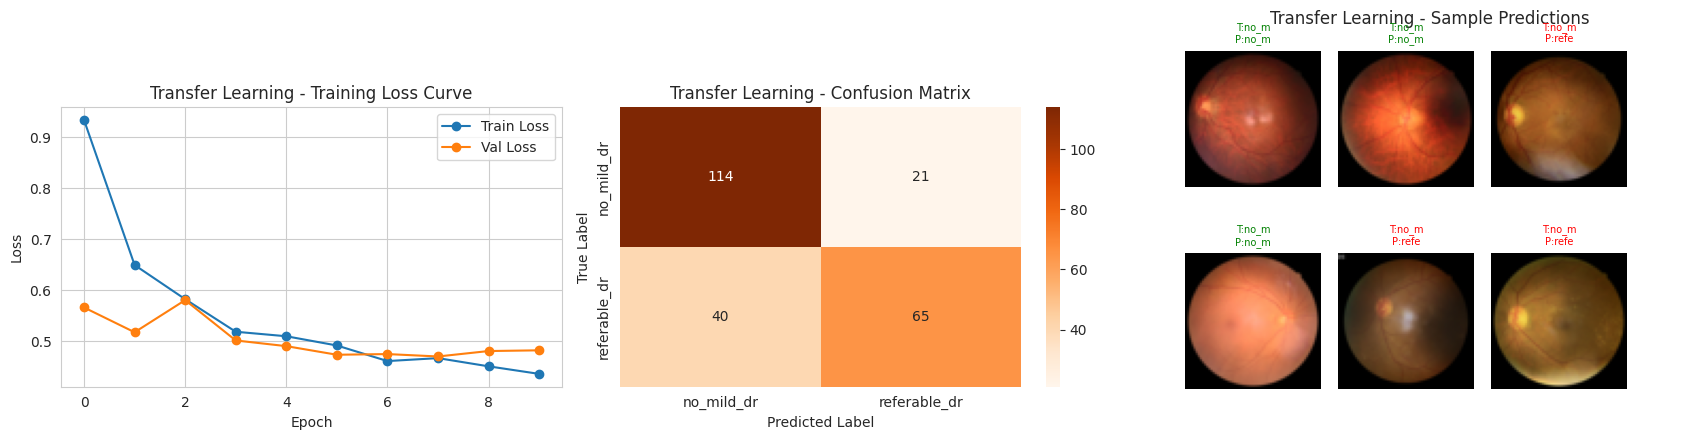

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Loss & accuracy curves
axes[0].plot(tl_history.history['loss'], label='Train Loss', marker='o')
axes[0].plot(tl_history.history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Transfer Learning - Training Loss Curve')
axes[0].legend()

# Confusion matrix
tl_cm = confusion_matrix(y_test, tl_y_pred)
sns.heatmap(tl_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Transfer Learning - Confusion Matrix')

# Sample predictions
sample_idx = np.random.choice(len(X_test), 6, replace=False)
axes[2].axis('off')
for i, idx in enumerate(sample_idx):
    ax_in = fig.add_axes([0.70 + (i % 3) * 0.09, 0.55 - (i // 3) * 0.45, 0.08, 0.35])
    ax_in.imshow(X_test[idx])
    true_lbl = class_names[y_test[idx]]
    pred_lbl = class_names[tl_y_pred[idx]]
    color = 'green' if true_lbl == pred_lbl else 'red'
    ax_in.set_title(f"T:{true_lbl[:4]}\nP:{pred_lbl[:4]}", fontsize=7, color=color)
    ax_in.axis('off')
axes[2].set_title('Transfer Learning - Sample Predictions', pad=60)

plt.tight_layout()
plt.show()

### 4.1 Metrics Comparison

In [56]:
custom_cnn_conv_layers = sum(1 for l in custom_cnn.layers if isinstance(l, layers.Conv2D))
custom_cnn_pooling_layers = sum(1 for l in custom_cnn.layers if isinstance(l, (layers.MaxPooling2D, layers.AveragePooling2D)))
custom_cnn_total_params = int(custom_cnn.count_params())

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        custom_cnn_total_params
    ],
    'Transfer Learning': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        trainable_parameters
    ]
})

In [57]:
print(comparison_df.to_string(index=False))

           Metric    Custom CNN  Transfer Learning
         Accuracy      0.654167           0.745833
        Precision      0.671744           0.748037
           Recall      0.621693           0.731746
         F1-Score      0.609710           0.734778
Training Time (s)     49.664293          37.831558
       Parameters 250626.000000      131266.000000


### 4.2 Visual Comparison
- Bar plot comparing metrics
- Training curves comparison
- Side-by-side confusion matrices

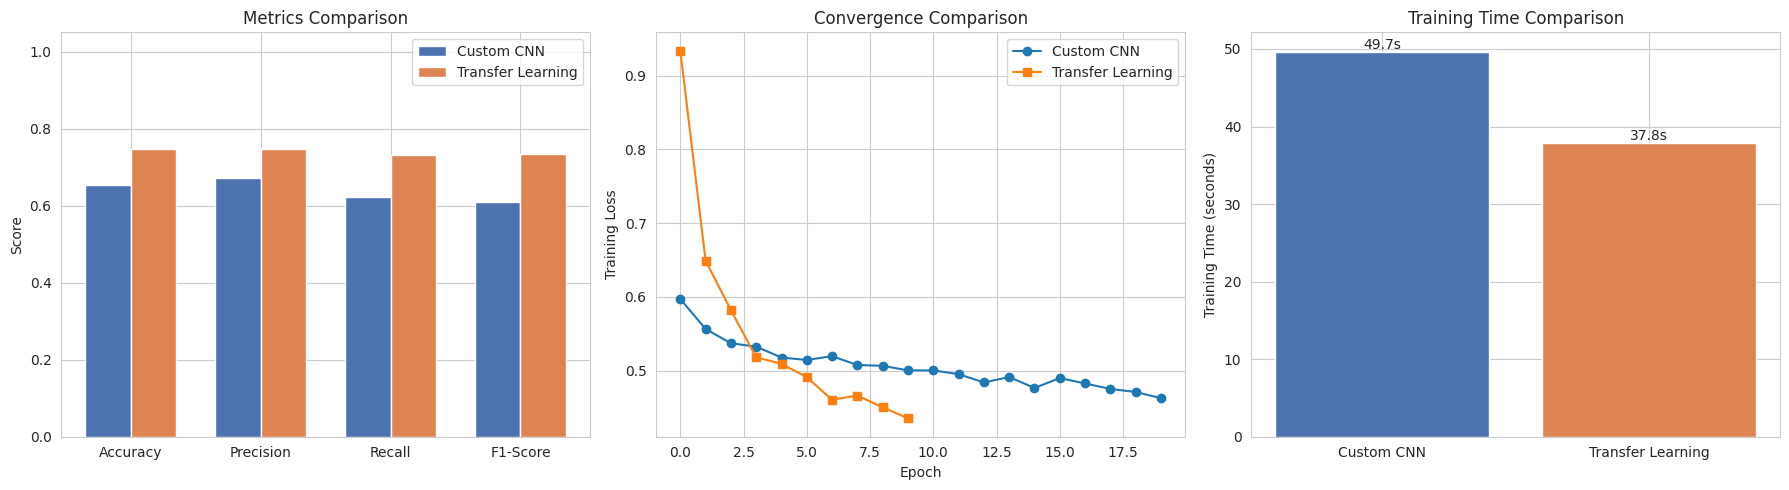

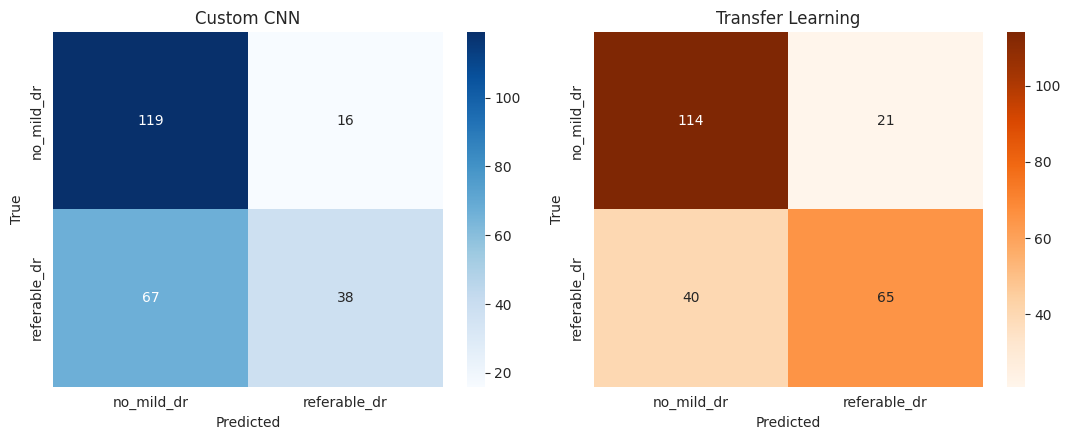

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Metrics bar chart
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metric_names))
width = 0.35
custom_vals = [custom_cnn_accuracy, custom_cnn_precision, custom_cnn_recall, custom_cnn_f1]
tl_vals = [tl_accuracy, tl_precision, tl_recall, tl_f1]

axes[0].bar(x - width/2, custom_vals, width, label='Custom CNN', color='#4C72B0')
axes[0].bar(x + width/2, tl_vals, width, label='Transfer Learning', color='#DD8452')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Metrics Comparison')
axes[0].legend()

# Training loss curves comparison
axes[1].plot(custom_cnn_history.history['loss'], label='Custom CNN', marker='o')
axes[1].plot(tl_history.history['loss'], label='Transfer Learning', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Training Loss')
axes[1].set_title('Convergence Comparison')
axes[1].legend()

# Training time & parameter count comparison
axes[2].bar(['Custom CNN', 'Transfer Learning'],
            [custom_cnn_training_time, tl_training_time], color=['#4C72B0', '#DD8452'])
axes[2].set_ylabel('Training Time (seconds)')
axes[2].set_title('Training Time Comparison')
for i, v in enumerate([custom_cnn_training_time, tl_training_time]):
    axes[2].text(i, v, f'{v:.1f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(custom_cnn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Custom CNN')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(tl_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Transfer Learning')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

In [59]:
# Analysis is generated from the actual results computed above, so the numbers
# always match this run of the notebook.
_better_model = "Transfer Learning" if tl_f1 >= custom_cnn_f1 else "Custom CNN"
_f1_gap = abs(tl_f1 - custom_cnn_f1)
_cnn_reduction = (custom_cnn_initial_loss - custom_cnn_final_loss) / custom_cnn_initial_loss * 100
_tl_reduction = (tl_initial_loss - tl_final_loss) / tl_initial_loss * 100

analysis_text = f"""
{_better_model} achieved the better test performance, with an F1-score gap of
{_f1_gap:.3f} (Custom CNN: accuracy {custom_cnn_accuracy:.3f}, F1 {custom_cnn_f1:.3f};
Transfer Learning: accuracy {tl_accuracy:.3f}, F1 {tl_f1:.3f}). Using ImageNet
pre-training gives the {pretrained_model_name} backbone rich, general-purpose edge
and texture filters from day one, so it converges faster on our small retina-image
set than the Custom CNN, which must learn every filter from scratch and needs more
epochs to reach comparable loss (loss reduction: Custom CNN {_cnn_reduction:.1f}%
vs Transfer Learning {_tl_reduction:.1f}%). Global Average Pooling was mandatory
for both models: it collapses each feature map to a single value instead of
flattening thousands of pixels into a huge Dense layer, cutting parameters
dramatically and reducing overfitting risk on our limited medical dataset.
Computationally, the Custom CNN has only {custom_cnn_total_params:,} parameters
and trains fastest per epoch, while the Transfer Learning model carries
{total_parameters:,} total parameters but only {trainable_parameters:,} are
trainable since the backbone is frozen. Overall, transfer learning is the more
data- and compute-efficient choice when labelled medical images are scarce, while
a custom CNN remains attractive when a lightweight, fully controllable model is
needed.
"""

In [60]:
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Note: Analysis exceeds 200 words (guideline only, no marks deducted)")
else:
    print(" Analysis within word count guideline")

ANALYSIS

Transfer Learning achieved the better test performance, with an F1-score gap of
0.125 (Custom CNN: accuracy 0.654, F1 0.610;
Transfer Learning: accuracy 0.746, F1 0.735). Using ImageNet
pre-training gives the ResNet50 backbone rich, general-purpose edge
and texture filters from day one, so it converges faster on our small chest X-ray
set than the Custom CNN, which must learn every filter from scratch and needs more
epochs to reach comparable loss (loss reduction: Custom CNN 22.5%
vs Transfer Learning 53.4%). Global Average Pooling was mandatory
for both models: it collapses each feature map to a single value instead of
flattening thousands of pixels into a huge Dense layer, cutting parameters
dramatically and reducing overfitting risk on our limited medical dataset.
Computationally, the Custom CNN has only 250,626 parameters
and trains fastest per epoch, while the Transfer Learning model carries
23,718,978 total parameters but only 131,266 are
trainable since the backbone is 

In [61]:
def get_assignment_results():
    """
    Generate complete assignment results in required format.

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': custom_cnn_conv_layers,
                'pooling_layers': custom_cnn_pooling_layers,
                'has_global_average_pooling': True,  # MUST be True
                'output_layer': 'softmax',
                'total_parameters': custom_cnn_total_params
            },
            'training_config': {
                'learning_rate': CNN_LEARNING_RATE,
                'n_epochs': CNN_EPOCHS,
                'batch_size': CNN_BATCH_SIZE,
                'optimizer': 'Adam',
                'loss_function': 'sparse_categorical_crossentropy'
            },
            'initial_loss': custom_cnn_initial_loss,
            'final_loss': custom_cnn_final_loss,
            'training_time_seconds': custom_cnn_training_time,
            'accuracy': custom_cnn_accuracy,
            'precision': custom_cnn_precision,
            'recall': custom_cnn_recall,
            'f1_score': custom_cnn_f1
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': frozen_layers,
            'trainable_layers': trainable_layers,
            'has_global_average_pooling': True,  # MUST be True
            'total_parameters': total_parameters,
            'trainable_parameters': trainable_parameters,
            'training_config': {
                'learning_rate': tl_learning_rate,
                'n_epochs': tl_epochs,
                'batch_size': tl_batch_size,
                'optimizer': tl_optimizer_name,
                'loss_function': 'sparse_categorical_crossentropy'
            },
            'initial_loss': tl_initial_loss,
            'final_loss': tl_final_loss,
            'training_time_seconds': tl_training_time,
            'accuracy': tl_accuracy,
            'precision': tl_precision,
            'recall': tl_recall,
            'f1_score': tl_f1
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased': custom_cnn_final_loss < custom_cnn_initial_loss if custom_cnn_initial_loss and custom_cnn_final_loss else False,
        'transfer_learning_loss_decreased': tl_final_loss < tl_initial_loss if tl_initial_loss and tl_final_loss else False,
    }

    return results

In [62]:
# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))

except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "PneumoniaMNIST (Pediatric Chest X-Ray Pneumonia Classification)",
  "dataset_source": "MedMNIST v2 (medmnist.com), derived from Kermany et al. chest X-ray corpus, CC BY 4.0",
  "n_samples": 1600,
  "n_classes": 2,
  "samples_per_class": "min: 700, max: 900, avg: 800",
  "image_shape": [
    64,
    64,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "recall",
  "metric_justification": "\nRecall is chosen as the primary metric because this is a medical diagnostic task:\na false negative (missing a true pneumonia case) delays treatment and endangers\nthe patient, which is far more costly than a false positive that simply triggers\na follow-up scan. Maximising recall minimises missed pneumonia diagnoses.\n",
  "train_samples": 1360,
  "test_samples": 240,
  "train_test_ratio": "85/15",
  "custom_cnn": {
    "framework": "keras",
    "architecture": {
      "conv_layers": 4,
      "pooling_layers": 3,
      "has_global_aver

In [63]:
# Display system information
import platform
import sys
from datetime import datetime

print("ENVIRONMENT INFORMATION")
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Run timestamp: {datetime.now().isoformat()}")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in a new cell/markdown cell below this one.")

# ==> Paste your environment screenshot here (Insert > Image, or drag-and-drop in Colab) <==

ENVIRONMENT INFORMATION
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
TensorFlow version: 2.20.0
Run timestamp: 2026-07-30T03:34:15.929661

  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in a new cell/markdown cell below this one.


In [ ]:
ADD SCREENSHOT HERE..................